In [ ]:
import re
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def parse_stat(text):
    if pd.isna(text) or isinstance(text, (int, float)): return float(text or 0.0)
    try: return float(re.split('±', str(text))[0])
    except: return 0.0

# 1. 数据配置与基准字号声明
df = pd.read_csv('External/all_metrics_summary.csv')
target_method, FS = 'SPE', 16 
methods_list = ['AB_MIL', 'TRANS_MIL', 'CLAM_MB_MIL', 'CLAM_SB_MIL', 'WIKG_MIL', 'MAMBA2D_MIL', 'AEM_MIL', 'MICO_MIL', 'MSM_MIL', 'TDA_MIL', 'GDF_MIL', 'SPE']
df = df[df['method'].isin(methods_list)].reset_index(drop=True)

perf_metrics = ['acc', 'bacc', 'macro_auc', 'macro_f1', 'quadratic_kappa']

metrics_map = {
    'acc': 'Accuracy',
    'bacc': 'Bal. Acc.',
    'macro_auc': 'Macro AUC',
    'macro_f1': 'Macro F1',
    'quadratic_kappa': 'Kappa'
}
colors = {'top1': '#D32F2F', 'top2': '#2E7D32', 'top3': '#1565C0', 'target_out': '#5E35B1', 'others': '#E0E4E8', 'range': '#F4F5F7'}

fig, ax = plt.subplots(figsize=(14, 8.5), dpi=120)
sns.set_style("white")

# 2. 核心循环：一体化处理点与全局有序向左迭代排队机制
for i, m in enumerate(perf_metrics):
    sdf = pd.DataFrame({'method': df['method'], 'val': df[m].apply(parse_stat)}).sort_values('val', ascending=False).reset_index(drop=True)
    v_min, v_max = sdf['val'].min(), sdf['val'].max()
    sdf['plot_x'] = 0.18 + (sdf['val'] - v_min) / (v_max - v_min + 1e-9) * 0.67

    # 绘制背景灰色跑道
    ax.hlines(y=i, xmin=0.15, xmax=0.88, color=colors['range'], linewidth=16, zorder=1, capstyle='round')

    # 身份标记
    top3_df = sdf.iloc[:3].copy()
    top3_df['style'] = ['top1', 'top2', 'top3']

    # 跌出前三的目标行收集
    target_in_top3 = target_method in top3_df['method'].values
    target_row = sdf[sdf['method'] == target_method].copy() if not target_in_top3 and not sdf[sdf['method'] == target_method].empty else pd.DataFrame()
    if not target_row.empty: target_row['style'] = 'target_out'

    # 批量绘制普通基线点
    others_df = sdf[~sdf['method'].isin(list(top3_df['method']) + list(target_row['method']) if not target_row.empty else list(top3_df['method']))]
    ax.scatter(others_df['plot_x'], [i] * len(others_df), color=colors['others'], s=55, alpha=0.7, zorder=2)

    ax.scatter(top3_df['plot_x'], [i] * len(top3_df), color=colors['top1'], s=110, edgecolors='white', linewidths=1.5, zorder=4)
    if not target_row.empty:
        ax.scatter(target_row['plot_x'], [i] * len(target_row), color=colors['target_out'], s=110, edgecolors='white', linewidths=1.5, zorder=4)
    # 碰撞
    positions = pd.concat([top3_df, target_row]).set_index('style').loc[['top1', 'top2', 'top3', 'target_out'] if not target_row.empty else ['top1', 'top2', 'top3']].reset_index()

    occupied_pos = []
    threshold, offset = 0.055, 0.05

    # 从 Top-1 (SPE)开始，固定最右侧。tx = row['plot_x']，ha = 'right'。
    occupied_pos.append({'tx': positions.loc[0, 'plot_x'], 'ha': 'right'})

    # 遍历下一个高亮模型（ Top-2, Top-3, target_out）
    for _, row in positions.iloc[1:].iterrows():
        # 初始尝试位置
        tx = row['plot_x']
        ha = 'center'

        # 迭代向左偏移循环，直到无冲突，或达到最大次数（例如10次）。假设无冲突。
        count = 0
        while count < 10:
            collision = False
            for past in occupied_pos:
                if abs(tx - past['tx']) < threshold:
                    # 冲突：向左移动，更改ha为'right'
                    tx = tx - offset
                    ha = 'right'
                    collision = True
                    break # 跳出内循环
            if not collision:
                break # 无冲突，跳出外循环
            count += 1
        occupied_pos.append({'tx': tx, 'ha': ha})

    # ***************** 遍历并绘制高亮模型及其文本 *****************
    for rank, row in positions.iterrows():
        name, val = row['method'].replace('_MIL', ''), row['val']
        style_key = row['style']

        final_pos = occupied_pos[rank]
        font_w = 'bold' if row['method'] == target_method else 'semibold'

        # 绘图点
        ax.scatter(row['plot_x'], i, color=colors[style_key], s=110, edgecolors='white', linewidths=1.5, zorder=4)
        # 绘图文本（字号放大，linespacing=1.3)
        ax.text(final_pos['tx'], i - 0.28, f"{name}\n{val:.4f}", color=colors[style_key], ha=final_pos['ha'], va='top', 
                fontsize=FS-3, fontweight=font_w, linespacing=1.3,
                bbox=dict(boxstyle='round,pad=0.1', fc='white', ec='none', alpha=0.85))

# 3. 样式微调与字号无死角放大
ax.set_yticks(range(len(perf_metrics)), labels=[metrics_map[m] for m in perf_metrics], fontsize=FS + 2, fontweight='bold', color='#222222')
ax.set_xticks([])
ax.tick_params(left=False, axis='y', pad=-15)
ax.spines[:].set_visible(False)

# 4. 列表推导式一行优雅构建图例
lg_elms = [Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[k], markersize=10, label=l) 
           for k, l in [('top1', 'Top-1'), ('top2', 'Top-2'), ('top3', 'Top-3'), ('others', 'Other Baselines')]]
leg = ax.legend(handles=lg_elms, loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=4, frameon=True, fontsize=FS-2, edgecolor='#F0F0F0', facecolor='white')
for text in leg.get_texts(): text.set(color="#333333", weight="semibold")

plt.tight_layout()
plt.savefig('result-ext/mil-contrast.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

FS = 14
plt.rcParams.update({
    'font.size': FS,
    'axes.unicode_minus': False
})

df = pd.read_csv('External/Ensemble/Ensemble_Weighted_Result.csv')

specimens = ['CNB', 'RP', 'TURP']

C_BACC = '#1a5276'
C_SENS = '#922b21'
C_SPEC = '#1e8449'
C_LINE = '#bfc5c9'

fig, ax = plt.subplots(figsize=(6.8, 4.8), dpi=300)

y_pos = np.arange(len(specimens))[::-1]

for y, spec in zip(y_pos, specimens):
    sub = df[df['type'] == spec]
    t = sub['label'].values
    p = sub['prediction'].values

    tp = ((p == 1) & (t == 1)).sum()
    tn = ((p == 0) & (t == 0)).sum()
    fp = ((p == 1) & (t == 0)).sum()
    fn = ((p == 0) & (t == 1)).sum()

    sens = tp / (tp + fn)
    spec_v = tn / (tn + fp)
    bacc = (sens + spec_v) / 2

    ax.plot([sens, spec_v], [y, y], color=C_LINE, lw=3, zorder=1)

    ax.scatter(sens, y, s=120, color=C_SENS, marker='o',
               edgecolors='white', linewidths=1.5, zorder=3)
    ax.scatter(spec_v, y, s=120, color=C_SPEC, marker='D',
               edgecolors='white', linewidths=1.5, zorder=3)
    ax.scatter(bacc, y, s=240, color=C_BACC, marker='*',
               edgecolors='white', linewidths=1.5, zorder=4)

    ax.text(sens, y + 0.11, f'{sens:.3f}', ha='center', fontsize=10, color=C_SENS)
    ax.text(spec_v, y + 0.11, f'{spec_v:.3f}', ha='center', fontsize=10, color=C_SPEC)
    ax.text(bacc, y - 0.17, f'{bacc:.3f}', ha='center', fontsize=11, color=C_BACC, fontweight='bold')

ax.set_xlim(0.86, 1.00)
ax.set_ylim(-0.5, len(specimens) - 0.5)
ax.set_xticks(np.arange(0.86, 1.001, 0.02))
ax.set_yticks(y_pos)
ax.set_yticklabels(specimens)

ax.grid(axis='x', color='#e8e8e8', lw=0.8)
ax.grid(axis='y', color='#f0f0f0', lw=0.8)
ax.tick_params(axis='y', length=0)

ax.legend(
    handles=[
        Line2D([], [], marker='*', color='w', markerfacecolor=C_BACC,
               markersize=14, label='Bal. Acc.'),
        Line2D([], [], marker='o', color='w', markerfacecolor=C_SENS,
               markersize=10, label='Sensitivity'),
        Line2D([], [], marker='D', color='w', markerfacecolor=C_SPEC,
               markersize=10, label='Specificity')
    ],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.15),
    ncol=3,
    frameon=True,
    edgecolor='#f0f0f0'
)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('result-ext/specimen_dumbbell.svg', bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

FS = 14
plt.rcParams.update({
    'font.size': FS,
    'axes.unicode_minus': False
})

df = pd.read_csv('External/Ensemble/Ensemble_Weighted_Result.csv')

centers = ['301', 'YNZL', 'FJSL', 'Total']
colors = {'bacc': '#1a5276', 'sens': '#922b21', 'spec': '#1e8449'}
markers = {'bacc': '*', 'sens': 'o', 'spec': 'D'}

fig, ax = plt.subplots(figsize=(7.2, 4.8), dpi=300)

y_pos = np.arange(len(centers))[::-1]

for y, center in zip(y_pos, centers):
    sub = df if center == 'Total' else df[df['center'] == center]
    t, p = sub['label'].values, sub['prediction'].values

    tp = ((p == 1) & (t == 1)).sum()
    tn = ((p == 0) & (t == 0)).sum()
    fp = ((p == 1) & (t == 0)).sum()
    fn = ((p == 0) & (t == 1)).sum()

    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    bacc = (sens + spec) / 2

    ax.plot([sens, spec], [y, y], color='#bfc5c9', lw=3, zorder=1)

    ax.scatter(sens, y, s=120, color=colors['sens'], marker=markers['sens'],
               edgecolors='white', linewidths=1.5, zorder=3)
    ax.scatter(spec, y, s=120, color=colors['spec'], marker=markers['spec'],
               edgecolors='white', linewidths=1.5, zorder=3)
    ax.scatter(bacc, y, s=240, color=colors['bacc'], marker=markers['bacc'],
               edgecolors='white', linewidths=1.5, zorder=4)
    if center == 'Total':
        ax.text(bacc, y - 0.26, f'{bacc:.3f}', ha='center', fontsize=11, color=colors['bacc'], fontweight='bold')
    else:
        label_y = y + 0.14
        ax.text(sens, label_y, f'{sens:.3f}', ha='center',  fontsize=10, color=colors['sens'])
        ax.text(spec, label_y, f'{spec:.3f}', ha='center', fontsize=10, color=colors['spec'])
        ax.text(bacc, y - 0.26, f'{bacc:.3f}', ha='center', fontsize=11, color=colors['bacc'], fontweight='bold')

ax.set_xlim(0.84, 1.00)
ax.set_xticks(np.arange(0.84, 1.001, 0.02))
ax.set_ylim(-0.5, len(centers) - 0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(centers)

ax.grid(axis='x', color='#e8e8e8', lw=0.8)
ax.grid(axis='y', color='#f0f0f0', lw=0.8)
ax.tick_params(axis='y', length=0)

ax.legend(
    handles=[
        Line2D([], [], marker='*', color='w', markerfacecolor=colors['bacc'], markersize=14, label='Bal. Acc.'),
        Line2D([], [], marker='o', color='w', markerfacecolor=colors['sens'], markersize=10, label='Sensitivity'),
        Line2D([], [], marker='D', color='w', markerfacecolor=colors['spec'], markersize=10, label='Specificity')
    ],
    loc='upper center',
    bbox_to_anchor=(0.5, 1.13),
    ncol=3,
    frameon=True,
    edgecolor='#f0f0f0'
)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_linewidth(1.5)

plt.tight_layout()
plt.savefig('result-ext/center_dumbbell.svg', bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

BASE_FONT_SIZE = 16
FONT_CELL = BASE_FONT_SIZE + 2
FONT_TICK = BASE_FONT_SIZE
FONT_TITLE = BASE_FONT_SIZE + 4
FONT_LABEL = BASE_FONT_SIZE + 5

df = pd.read_csv('External/Ensemble/Ensemble_Weighted_Result.csv')

centers = ['301', 'YNZL', 'FJSL']
types = ['CNB', 'RP', 'TURP']

cmap = LinearSegmentedColormap.from_list(
    "MorandiBlues",
    ["#f7f5f0", "#d3dcde", "#a9bcc4", "#7fa1ad", "#577987", "#3d5a66"]
)

sns.set_style("white")
fig, axes = plt.subplots(3, 3, figsize=(13, 12), facecolor='white')
plt.subplots_adjust(wspace=0.08, hspace=0.08)

for r, t in enumerate(types):
    for c, center in enumerate(centers):
        ax = axes[r, c]
        sub = df[(df['center'] == center) & (df['type'] == t)]

        if sub.empty:
            ax.axis('off')
            continue

        cm = confusion_matrix(sub['label'], sub['prediction'], labels=[0, 1])
        cm_norm = confusion_matrix(sub['label'], sub['prediction'], labels=[0, 1], normalize='true')

        sns.heatmap(
            cm_norm, cmap=cmap, cbar=False, ax=ax,
            linewidths=1.5, linecolor='white',
            vmin=0, vmax=1, square=True,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant']
        )

        for (i, j), val in np.ndenumerate(cm_norm):
            ax.text(
                j + 0.5, i + 0.5,
                f"{val:.1%}\n(n={cm[i, j]})",
                ha="center", va="center",
                color="#f7f5f0" if val > 0.5 else "#2f3e46",
                fontsize=FONT_CELL,
                fontweight='bold'
            )

        ax.tick_params(length=0)
        ax.set_xticklabels(['Benign', 'Malignant'], fontsize=FONT_TICK, fontweight='semibold', color='#2f3e46')
        ax.set_yticklabels(['Benign', 'Malignant'], fontsize=FONT_TICK, rotation=0, fontweight='semibold', color='#2f3e46')

        if r == 0:
            ax.set_title(center, fontweight='bold', fontsize=FONT_TITLE, pad=12, color='#2f3e46')
        if c == 0:
            ax.set_ylabel(t, fontweight='bold', fontsize=FONT_LABEL, labelpad=18, color='#2f3e46')
        else:
            ax.set_ylabel('')
        if r < len(types) - 1:
            ax.set_xticklabels([])
        if c > 0:
            ax.set_yticklabels([])
    for r, t in enumerate(types):
        left_ax = axes[r, 0]
        left_ax.set_yticklabels(["Benign", "Malignant"], fontsize=FONT_TICK, rotation=90, fontweight="semibold", color='#2f3e46', va='center')
        left_ax.set_ylabel(t, fontweight="bold", fontsize=FONT_LABEL, labelpad=15, color='#2f3e46')

plt.savefig('result-ext/ext_cm.svg', bbox_inches='tight', facecolor='white', dpi=300)
plt.show()

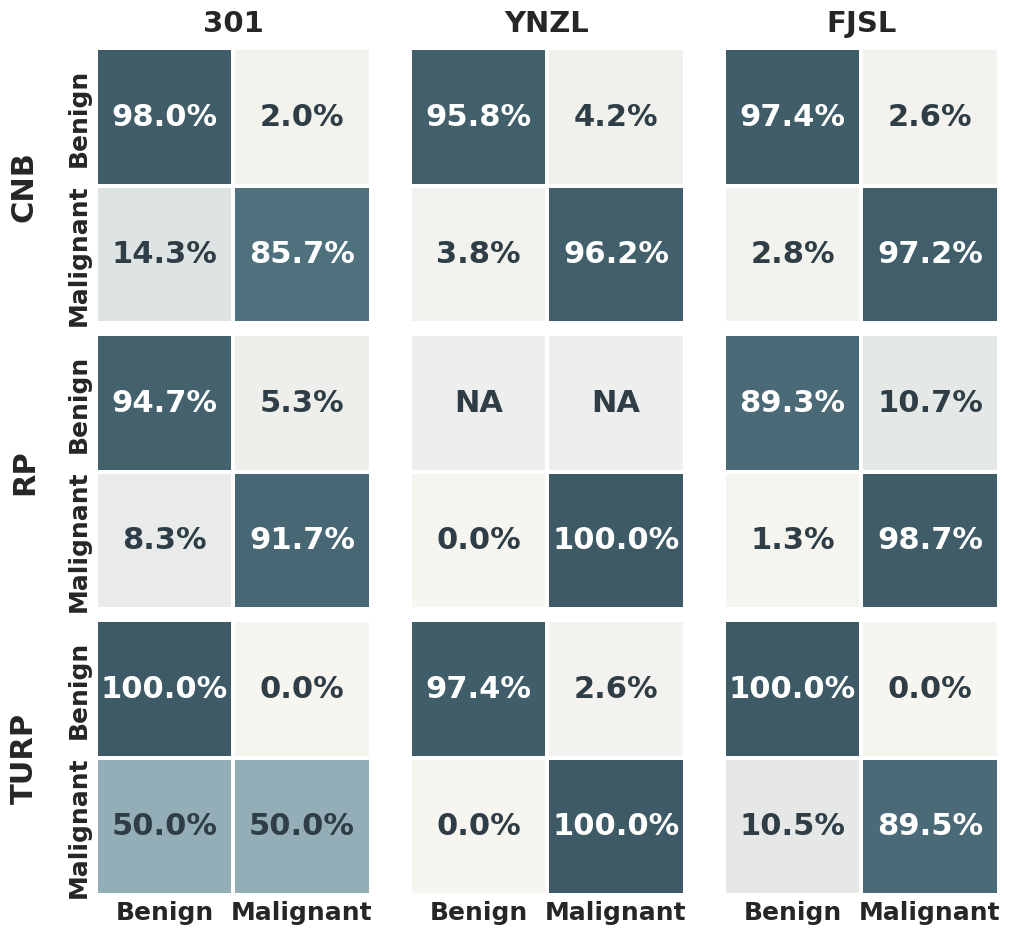

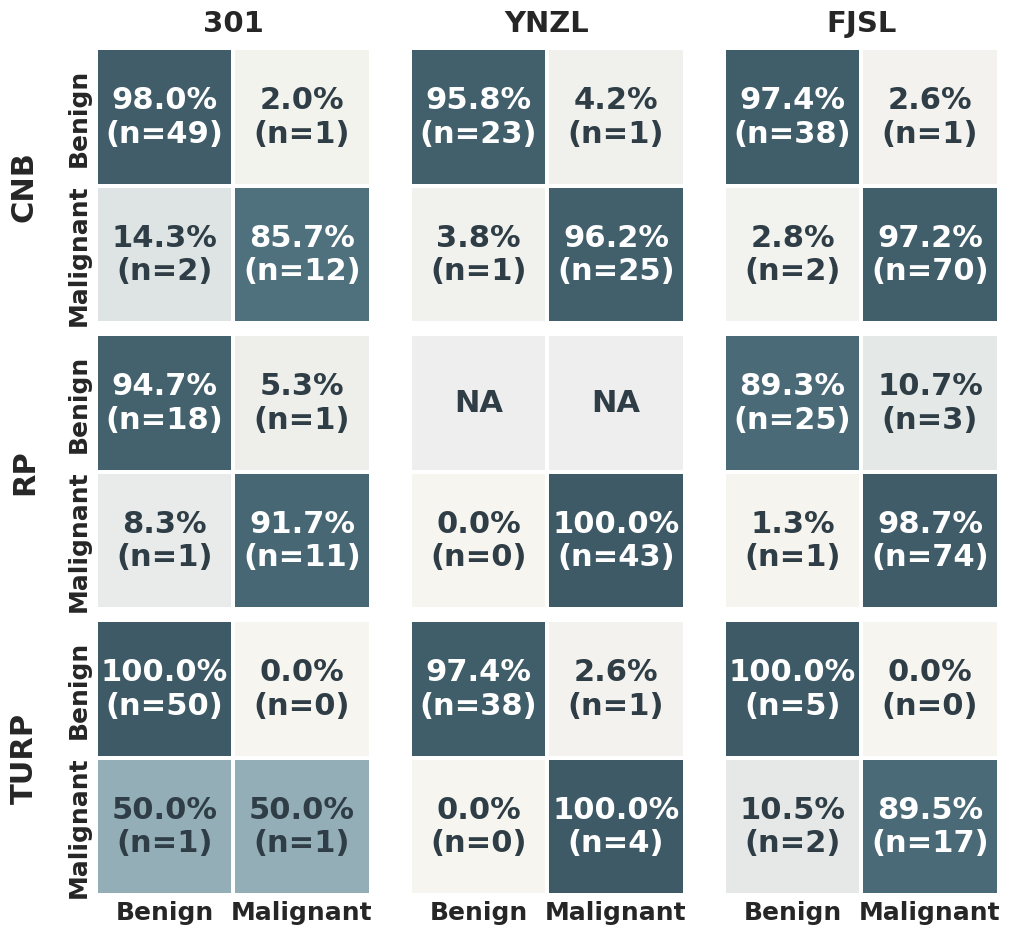

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

FS = 18
df = pd.read_csv('External/Ensemble/Ensemble_Weighted_Result.csv')

centers = ['301', 'YNZL', 'FJSL']
types = ['CNB', 'RP', 'TURP']

cmap = LinearSegmentedColormap.from_list('MorandiBlues', ['#f7f5f0', '#d3dcde', '#a9bcc4', '#7fa1ad', '#577987', '#3d5a66'])
cmap.set_bad('#eeeeee')

sns.set_style('white')


def plot_confusion_grid(show_counts=False, output='ext_cm.svg'):
    fig, axes = plt.subplots(3, 3, figsize=(12, 11))
    plt.subplots_adjust(wspace=0.04, hspace=0.04)

    for r, specimen in enumerate(types):
        for c, center in enumerate(centers):
            ax = axes[r, c]
            sub = df[(df['center'] == center) & (df['type'] == specimen)]

            if sub.empty:
                ax.axis('off')
                continue

            cm = confusion_matrix(sub['label'], sub['prediction'], labels=[0, 1])
            cm_norm = confusion_matrix(sub['label'], sub['prediction'], labels=[0, 1], normalize='true')

            is_ynzl_rp = (center == 'YNZL') and (specimen == 'RP')
            cm_plot = cm_norm.astype(float).copy()
            if is_ynzl_rp:
                cm_plot[0, :] = np.nan

            sns.heatmap(cm_plot, ax=ax, cmap=cmap, vmin=0, vmax=1, cbar=False, square=True, linewidths=1.5, linecolor='white', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])

            for (i, j), value in np.ndenumerate(cm_norm):
                if is_ynzl_rp and i == 0:
                    text, color = 'NA', '#2f3e46'
                else:
                    text = f'{value:.1%}'
                    if show_counts:
                        text += f'\n(n={cm[i, j]})'
                    color = 'white' if value > 0.55 else '#2f3e46'

                ax.text(j + 0.5, i + 0.5, text, ha='center', va='center', fontsize=FS + 4, fontweight='bold', color=color)

            ax.tick_params(length=0)

            if r == 0:
                ax.set_title(center, fontsize=FS + 3, fontweight='bold', pad=12)

            if r == len(types) - 1:
                ax.set_xticklabels(['Benign', 'Malignant'], fontsize=FS, fontweight='semibold')
            else:
                ax.set_xticklabels([])

            if c == 0:
                ax.set_yticklabels(['Benign', 'Malignant'], fontsize=FS, rotation=90, va='center', fontweight='semibold')
                ax.set_ylabel(specimen, fontsize=FS + 4, fontweight='bold', labelpad=20)
            else:
                ax.set_yticklabels([])
                ax.set_ylabel('')

            ax.set_xlabel('')

    os.makedirs(os.path.dirname(output), exist_ok=True)
    plt.savefig(output, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()


plot_confusion_grid(show_counts=False, output='result-ext/ext_cm.svg')
plot_confusion_grid(show_counts=True, output='result-ext/ext_cm_counts.svg')